# CARS Model Evaluation — Post-Processing

Воспроизводимая визуализация `results_collected/{host}/.../metrics.json`.

Артефакты:
- bar-charts по семействам моделей (detection / classification / ocr) → `plots/*.png`
- US baseline vs Nomeroff RU side-by-side

Запуск: kernel = venv проекта, working dir = корень репо.

**Caveat:** per-sample predictions evaluate.py не пишет (только агрегаты), поэтому PR-curves и confusion matrices здесь не строятся — это отдельная итерация после расширения eval-пайплайна.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
# When the notebook lives in notebooks/, cwd is usually notebooks/ — climb to repo root.
if (ROOT / 'results_collected').exists():
    REPO = ROOT
elif (ROOT.parent / 'results_collected').exists():
    REPO = ROOT.parent
else:
    raise FileNotFoundError('results_collected/ not found above cwd')

COLLECTED = REPO / 'results_collected'
PLOTS = REPO / 'plots'
PLOTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
print('Repo:', REPO)
print('Plots dir:', PLOTS)

Repo: /home/vallo/CarCV-metrics/.claude/worktrees/exp+validation-campaign-2026-05-17
Plots dir: /home/vallo/CarCV-metrics/.claude/worktrees/exp+validation-campaign-2026-05-17/plots


In [2]:
# Discovery: walk every metrics.json, classify by family, flatten to a row per metric.
FAMILY_KEYS = {
    'detection': ['precision', 'recall', 'f1', 'map50'],
    'classification': ['top1_accuracy', 'top3_accuracy'],
    'ocr': ['char_accuracy', 'full_plate_accuracy'],
}

def infer_family(metrics):
    keys = set(metrics)
    if {'precision', 'recall', 'f1'} <= keys:
        return 'detection'
    if 'top1_accuracy' in keys:
        return 'classification'
    if 'char_accuracy' in keys or 'full_plate_accuracy' in keys:
        return 'ocr'
    return 'unknown'

rows = []
for mj in sorted(COLLECTED.glob('**/metrics.json')):
    data = json.loads(mj.read_text())
    if 'error' in data:
        continue
    metrics = data.get('metrics', {})
    parts = mj.relative_to(COLLECTED).parts
    host = parts[0]
    model = parts[2] if len(parts) >= 4 and parts[1] == 'results' else parts[1]
    fam = infer_family(metrics)
    thresholds = data.get('thresholds', {})
    for k in FAMILY_KEYS.get(fam, []):
        if k not in metrics:
            continue
        tinfo = thresholds.get(k, {})
        rows.append({
            'host': host, 'model': model, 'family': fam, 'metric': k,
            'value': metrics[k],
            'threshold': tinfo.get('threshold'),
            'status': tinfo.get('status'),
        })

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} (metric, model, host) rows from {df.host.nunique()} host(s).')
df.head(20)

Loaded 38 (metric, model, host) rows from 3 host(s).


,host,model,family,metric,value,threshold,status
0,qudata2,lpdnet,detection,precision,0.8837,0.70,PASS
1,qudata2,lpdnet,detection,recall,0.2961,0.80,FAIL
2,qudata2,lpdnet,detection,f1,0.4436,NaN,None
3,qudata2,lpdnet,detection,map50,0.2617,NaN,None
4,qudata2,lprnet,ocr,char_accuracy,0.5903,0.90,FAIL
5,qudata2,lprnet,ocr,full_plate_accuracy,0.0621,0.80,FAIL
6,qudata2,trafficcamnet,detection,precision,0.1671,0.90,FAIL
7,qudata2,trafficcamnet,detection,recall,0.0316,0.85,FAIL
8,qudata2,trafficcamnet,detection,f1,0.0531,0.87,FAIL
9,qudata2,trafficcamnet,detection,map50,0.0192,NaN,None


## Pass / Fail counts по семействам

status          FAIL  PASS  —
family                       
classification     7     0  1
detection         11     4  9
ocr                4     2  0


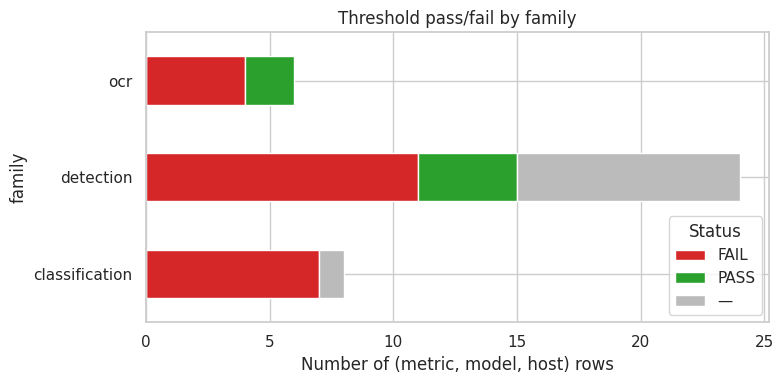

In [3]:
status_counts = (df.assign(status=df.status.fillna('—'))
                   .groupby(['family', 'status']).size().unstack(fill_value=0))
print(status_counts)

fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind='barh', stacked=True, ax=ax,
                   color={'PASS': '#2ca02c', 'FAIL': '#d62728', '—': '#bbbbbb'})
ax.set_xlabel('Number of (metric, model, host) rows')
ax.set_title('Threshold pass/fail by family')
ax.legend(title='Status', loc='lower right')
fig.tight_layout()
fig.savefig(PLOTS / 'pass_fail_by_family.png', dpi=120)
plt.show()

## Detection (Precision / Recall / F1 / mAP@0.5)

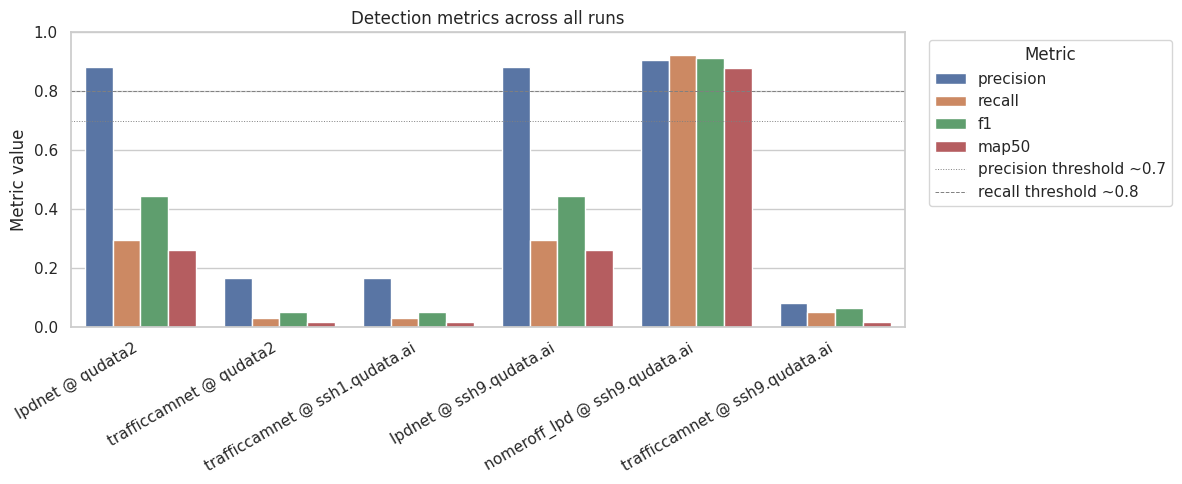

In [4]:
det = df[df.family == 'detection'].copy()
det['run'] = det.model + ' @ ' + det.host

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=det, x='run', y='value', hue='metric', ax=ax)
ax.axhline(0.7, color='gray', linestyle=':', linewidth=0.7, label='precision threshold ~0.7')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.7, label='recall threshold ~0.8')
ax.set_xlabel('')
ax.set_ylabel('Metric value')
ax.set_title('Detection metrics across all runs')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(PLOTS / 'detection_metrics.png', dpi=120)
plt.show()

## OCR (Character / Full-plate accuracy)

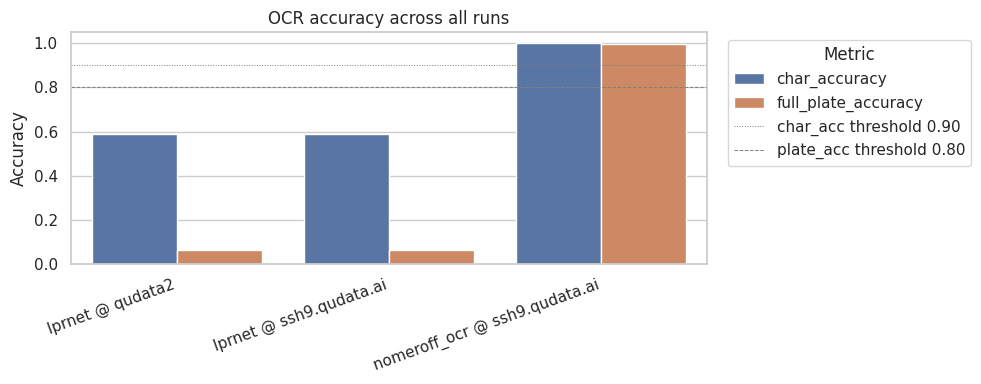

In [5]:
ocr = df[df.family == 'ocr'].copy()
ocr['run'] = ocr.model + ' @ ' + ocr.host

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=ocr, x='run', y='value', hue='metric', ax=ax)
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.7, label='char_acc threshold 0.90')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.7, label='plate_acc threshold 0.80')
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.set_title('OCR accuracy across all runs')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(PLOTS / 'ocr_metrics.png', dpi=120)
plt.show()

## Classification (Top-1 / Top-3)

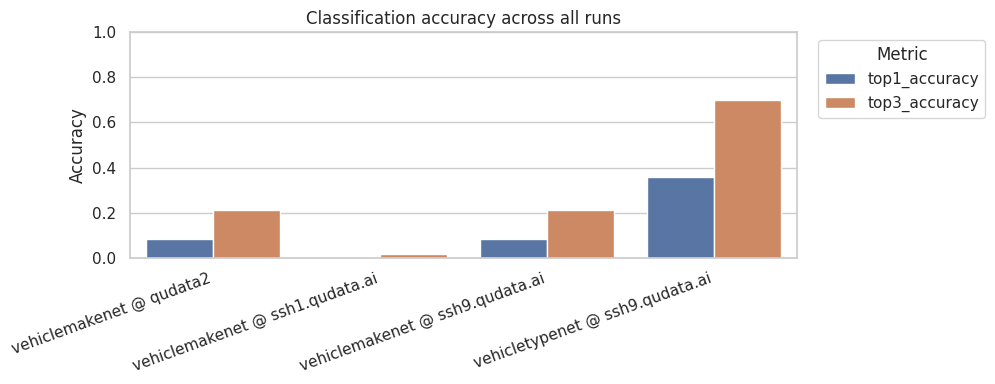

In [6]:
cls = df[df.family == 'classification'].copy()
cls['run'] = cls.model + ' @ ' + cls.host

if not cls.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=cls, x='run', y='value', hue='metric', ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Accuracy')
    ax.set_title('Classification accuracy across all runs')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=20)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    fig.savefig(PLOTS / 'classification_metrics.png', dpi=120)
    plt.show()
else:
    print('No classification runs found.')

## US baseline vs Nomeroff RU — side-by-side

Только пары моделей, прогнанные на одном датасете: `lpdnet`↔`nomeroff_lpd` (data/nomeroff_lp), `lprnet`↔`nomeroff_ocr` (data/nomeroff_ocr_ru). Δ ≈ улучшение от перехода на RU-specific модель.

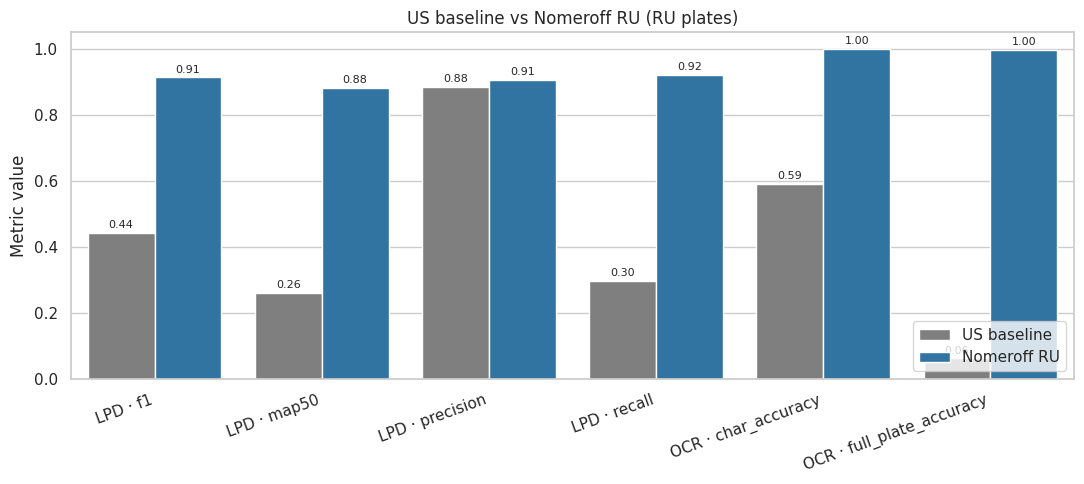

side                          Nomeroff RU  US baseline   delta
pipeline metric                                               
LPD      f1                        0.9138       0.4436  0.4702
         map50                     0.8806       0.2617  0.6189
         precision                 0.9056       0.8837  0.0219
         recall                    0.9221       0.2961  0.6260
OCR      char_accuracy             0.9995       0.5903  0.4092
         full_plate_accuracy       0.9978       0.0621  0.9357

In [7]:
PAIRS = [
    ('LPD', 'lpdnet', 'nomeroff_lpd'),
    ('OCR', 'lprnet', 'nomeroff_ocr'),
]

# Take the most recent (highest host name; ssh9 > qudata2 alphabetically — acceptable for current data).
# In practice both lpdnet/lprnet have identical metrics across hosts (same model, same data).
comp_rows = []
for pipe, us_name, nm_name in PAIRS:
    us = df[df.model == us_name]
    nm = df[df.model == nm_name]
    if us.empty or nm.empty:
        continue
    for metric in sorted(set(us.metric) & set(nm.metric)):
        u = us[us.metric == metric].value.iloc[0]
        n = nm[nm.metric == metric].value.iloc[0]
        comp_rows.append({'pipeline': pipe, 'metric': metric, 'side': 'US baseline', 'value': u})
        comp_rows.append({'pipeline': pipe, 'metric': metric, 'side': 'Nomeroff RU', 'value': n})

comp = pd.DataFrame(comp_rows)
comp['label'] = comp.pipeline + ' · ' + comp.metric

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=comp, x='label', y='value', hue='side',
            palette={'US baseline': '#7f7f7f', 'Nomeroff RU': '#1f77b4'}, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Metric value')
ax.set_title('US baseline vs Nomeroff RU (RU plates)')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
ax.legend(title='', loc='lower right')
fig.tight_layout()
fig.savefig(PLOTS / 'us_vs_nomeroff.png', dpi=120)
plt.show()

# Companion table
comp.pivot_table(index=['pipeline', 'metric'], columns='side', values='value').assign(
    delta=lambda d: d['Nomeroff RU'] - d['US baseline']
)

## Caveats / next steps

1. **Per-sample predictions не пишутся.** Текущий `deploy/evaluation/evaluate.py` сохраняет только агрегаты (`metrics.json`). PR-curves, confusion matrices, error-breakdown — отдельный кусок работы, требует расширения evaluate.py (например, `--save-predictions` flag → `results/<model>/predictions.parquet`).
2. **Сегментация BDD100K (weather × timeofday × scene)** — пока не применимо: TrafficCamNet прогонялся на COCO val2017 (нет BDD-метаданных). Зависит от Goal 4 (§6.5 dataset migration).
3. **vehiclemakenet @ ssh1 vs qudata2 расхождение** (top1 0.002 vs 0.083): qudata2 — sample 700 (top class «toyota» 28%), ssh1 — full mad-cars 4960 (всё схлопывается в «acura»). Label-mapping mad-cars→NGC проблема обозначена в Goal 4.